In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('valid_df_with_predictions.csv')
df

,sentiment,text,out_label_LR,out_label_Prompt_1,out_label_Prompt_2,out_label_Prompt_3,out_label_Prompt_4,out_label_Prompt_5
0,positive,These work great and are a better value than m...,positive,positive,positive,positive,positive,positive
1,negative,I replaced the all the suspension rods/shocks ...,positive,negative,negative,negative,negative,negative
2,positive,my old ones couldn't tolerate the heat and bec...,positive,positive,positive,positive,positive,positive
3,negative,This bracket will not fit the under counter wa...,negative,negative,negative,negative,negative,negative
4,positive,These work fairly well and save a lot of money...,negative,positive,positive,positive,positive,positive
...,...,...,...,...,...,...,...,...
695,negative,Installed this in my frig and a gush of black ...,negative,negative,negative,negative,negative,negative
696,negative,Does not fit my Samsung refrigerator.,negative,negative,negative,negative,negative,negative
697,positive,The video showing how it works was extremely a...,positive,positive,positive,positive,positive,positive
698,positive,"Did have a small issue putting it in, but it w...",positive,positive,positive,positive,positive,positive


In [18]:
from sklearn.metrics import f1_score
import pandas as pd

df["word_len"] = df["text"].astype(str).str.split().str.len()

bins = [0, 8, 15, 30, 45, float("inf")]
labels = ["1-8", "9-15", "16-30", "31-45", "46+"]
df["len_bin"] = pd.cut(df["word_len"], bins=bins, labels=labels, include_lowest=True)

models = [
    "out_label_LR",
    "out_label_Prompt_1",
    "out_label_Prompt_2",
    "out_label_Prompt_3",
    "out_label_Prompt_4",
    "out_label_Prompt_5"
]

result_df = pd.DataFrame({
    model: df.groupby("len_bin").apply(
        lambda x: f1_score(x["sentiment"], x[model], average="weighted")
    )
    for model in models
})

print(result_df)

         out_label_LR  out_label_Prompt_1  out_label_Prompt_2  \
len_bin                                                         
1-8          0.944504            0.932348            0.937341   
9-15         0.934970            0.922008            0.923333   
16-30        0.885185            0.894834            0.900742   
31-45        0.856414            0.887621            0.899853   
46+          0.824457            0.894674            0.894674   

         out_label_Prompt_3  out_label_Prompt_4  out_label_Prompt_5  
len_bin                                                              
1-8                0.912936            0.899006            0.897952  
9-15               0.914964            0.894276            0.901107  
16-30              0.894834            0.900742            0.877214  
31-45              0.875404            0.887004            0.874817  
46+                0.881072            0.873851            0.881072  


/var/folders/xq/dznpw7s50vdg77ddlcz18rvw0000gn/T/ipykernel_53056/1028744149.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model: df.groupby("len_bin").apply(
/var/folders/xq/dznpw7s50vdg77ddlcz18rvw0000gn/T/ipykernel_53056/1028744149.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model: df.groupby("len_bin").apply(
/var/folders/xq/dznpw7s50vdg77ddlcz18rvw0000gn/T/ipykernel_53056/1028744149.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future v

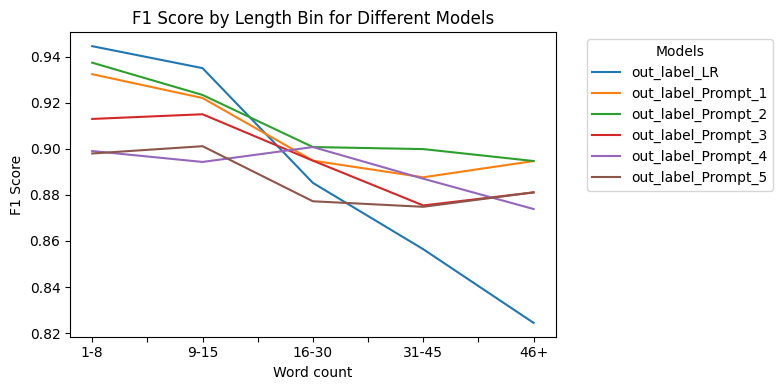

In [25]:
result_df.plot(kind='line', figsize=(8, 4))
plt.title('F1 Score by Length Bin for Different Models')
plt.xlabel('Word count')
plt.ylabel('F1 Score')
plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import f1_score
import pandas as pd

models = [
    "out_label_LR",
    "out_label_Prompt_1",
    "out_label_Prompt_2",
    "out_label_Prompt_3",
    "out_label_Prompt_4",
    "out_label_Prompt_5"
]

# Mark texts with contrast words
df["has_contrast"] = df["text"].astype(str).str.contains(
    r"\b(however|although|but)\b",
    case=False,
    regex=True
)

# More readable group names
df["contrast_group"] = df["has_contrast"].map({
    True: "contains_however_although_but",
    False: "does_not_contain_however_although_but"
})

# F1-score table: rows = contrast group, columns = models
result_df = pd.DataFrame({
    model: df.groupby("contrast_group").apply(
        lambda x: f1_score(x["sentiment"], x[model], average="weighted")
    )
    for model in models
})

print(result_df)
result_df.to_csv("analysis/contrast_analysis_results.csv", index=True)

                                       out_label_LR  out_label_Prompt_1  \
contrast_group                                                            
contains_however_although_but              0.828851            0.872847   
does_not_contain_however_although_but      0.912618            0.918849   

                                       out_label_Prompt_2  out_label_Prompt_3  \
contrast_group                                                                  
contains_however_although_but                    0.872847            0.852119   
does_not_contain_however_although_but            0.924032            0.909476   

                                       out_label_Prompt_4  out_label_Prompt_5  
contrast_group                                                                 
contains_however_although_but                    0.851466            0.844933  
does_not_contain_however_although_but            0.900454            0.897136  


/var/folders/xq/dznpw7s50vdg77ddlcz18rvw0000gn/T/ipykernel_53056/797108906.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_contrast"] = df["text"].astype(str).str.contains(
/var/folders/xq/dznpw7s50vdg77ddlcz18rvw0000gn/T/ipykernel_53056/797108906.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model: df.groupby("contrast_group").apply(
/var/folders/xq/dznpw7s50vdg77ddlcz18rvw0000gn/T/ipykernel_53056/797108906.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded